In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
#from optuna.integration import OptunaSearchCV  # альтернативный вариант, но мы реализуем свой цикл
from sklearn.utils import resample
import sklearn
sklearn.set_config(enable_metadata_routing=False) 

c:\Users\Admin\miniconda3\envs\smog\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Настройки для красивых графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [3]:
# Создаём папки для сохранения отчёта и графиков
REPORT_DIR = Path('../reports')
FIGURES_DIR = REPORT_DIR / 'figures'
REPORT_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR = Path("../models/artifacts")

In [4]:
# 1. Загрузка данных
DATA_PATH = '../data/raw/nigerian_mobile_money_full.parquet'
print(f"Загрузка данных из {DATA_PATH}...")
df = pd.read_parquet(DATA_PATH)

Загрузка данных из ../data/raw/nigerian_mobile_money_full.parquet...


In [5]:
# Базовые сведения
print("Данные загружены. Размер:", df.shape)
print("\nПервые 5 строк:")
display(df.head())

Данные загружены. Размер: (4000000, 13)

Первые 5 строк:


,transaction_id,wallet_id,timestamp,transaction_type,amount_ngn,fee_ngn,balance_after_ngn,agent_id,channel,device_os,kyc_tier,fraud_flag,churn_30d
0,90e956c0-7e3e-4207-8bbc-90de4c61d05e,WLT-00001530,2024-06-03 20:35:00,airtime,1000.0,10.0,917.204594,,ussd,android,tier2,False,False
1,3cff1814-4796-4e7e-91ff-2cc1240fe8d8,WLT-00001003,2024-04-01 08:34:00,cashin,1150.0,10.0,644.741704,AGT-00004700,ussd,android,tier2,False,False
2,9fb30da5-5e4e-453f-86cc-3cf842d211ac,WLT-00018460,2024-01-08 19:17:00,cashout,4850.0,10.0,3582.585292,AGT-00001615,app,android,tier1,False,False
3,6127f44f-6d23-4d9f-988f-54dcae598f4d,WLT-00000072,2024-04-14 23:10:00,p2p_send,9800.0,98.0,1546.044463,,ussd,android,tier3,False,False
4,f5ca608d-9ddb-40ca-a4ad-39c8474477cd,WLT-00017907,2024-06-14 07:10:00,billpay,1600.0,10.0,4361.698947,,app,feature_phone,tier2,False,False


In [6]:
# 2. Информация о типах данных и пропусках
print("\nИнформация о датафрейме:")
df.info()


Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000000 entries, 0 to 3999999
Data columns (total 13 columns):
 #   Column             Dtype         
---  ------             -----         
 0   transaction_id     object        
 1   wallet_id          object        
 2   timestamp          datetime64[ns]
 3   transaction_type   object        
 4   amount_ngn         float64       
 5   fee_ngn            float64       
 6   balance_after_ngn  float64       
 7   agent_id           object        
 8   channel            object        
 9   device_os          object        
 10  kyc_tier           object        
 11  fraud_flag         bool          
 12  churn_30d          bool          
dtypes: bool(2), datetime64[ns](1), float64(3), object(7)
memory usage: 343.3+ MB


In [7]:
# 2. Информация о типах данных и пропусках
print("\nИнформация о датафрейме:")
df.info()

print("\nПропуски по столбцам:")
missing = df.isnull().sum()
print(missing[missing > 0] if any(missing > 0) else "Нет пропусков.")


Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000000 entries, 0 to 3999999
Data columns (total 13 columns):
 #   Column             Dtype         
---  ------             -----         
 0   transaction_id     object        
 1   wallet_id          object        
 2   timestamp          datetime64[ns]
 3   transaction_type   object        
 4   amount_ngn         float64       
 5   fee_ngn            float64       
 6   balance_after_ngn  float64       
 7   agent_id           object        
 8   channel            object        
 9   device_os          object        
 10  kyc_tier           object        
 11  fraud_flag         bool          
 12  churn_30d          bool          
dtypes: bool(2), datetime64[ns](1), float64(3), object(7)
memory usage: 343.3+ MB

Пропуски по столбцам:
Нет пропусков.


In [8]:
# 3. Распределение классов
class_counts = df['fraud_flag'].value_counts()
class_percents = df['fraud_flag'].value_counts(normalize=True) * 100
print("\nРаспределение классов:")
print(class_counts)
print("\nПроценты:")
print(class_percents)



Распределение классов:
fraud_flag
False    3940000
True       60000
Name: count, dtype: int64

Проценты:
fraud_flag
False    98.5
True      1.5
Name: proportion, dtype: float64


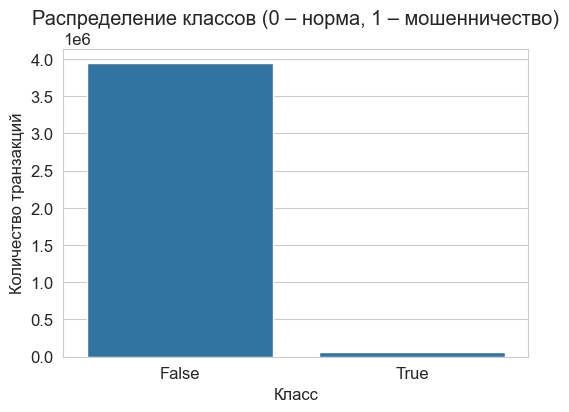

In [9]:
# Сохраним график распределения классов
plt.figure(figsize=(6,4))
sns.countplot(x='fraud_flag', data=df)
plt.title('Распределение классов (0 – норма, 1 – мошенничество)')
plt.xlabel('Класс')
plt.ylabel('Количество транзакций')
plt.show()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.close()

In [10]:
# 4. Выбросы для amount_ngn и balance_after_ngn (основные числовые признаки)
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers.shape[0], lower_bound, upper_bound

In [11]:
print("\nВыбросы (метод IQR):")
for col in ['amount_ngn', 'balance_after_ngn']:
    n_out, low, high = detect_outliers_iqr(df, col)
    print(f"{col}: {n_out} выбросов ({n_out/len(df)*100:.2f}%)")


Выбросы (метод IQR):
amount_ngn: 477971 выбросов (11.95%)
balance_after_ngn: 311041 выбросов (7.78%)


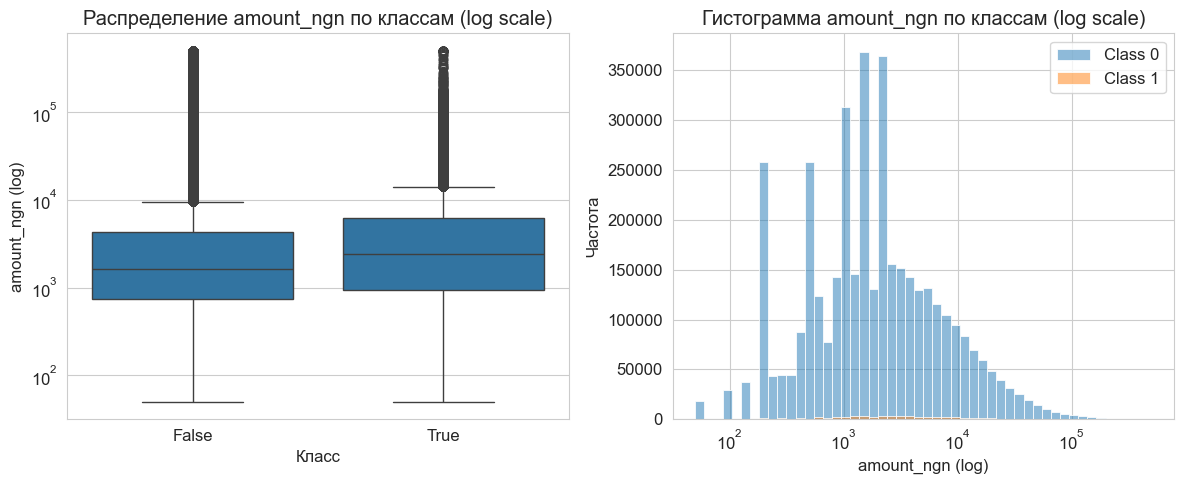

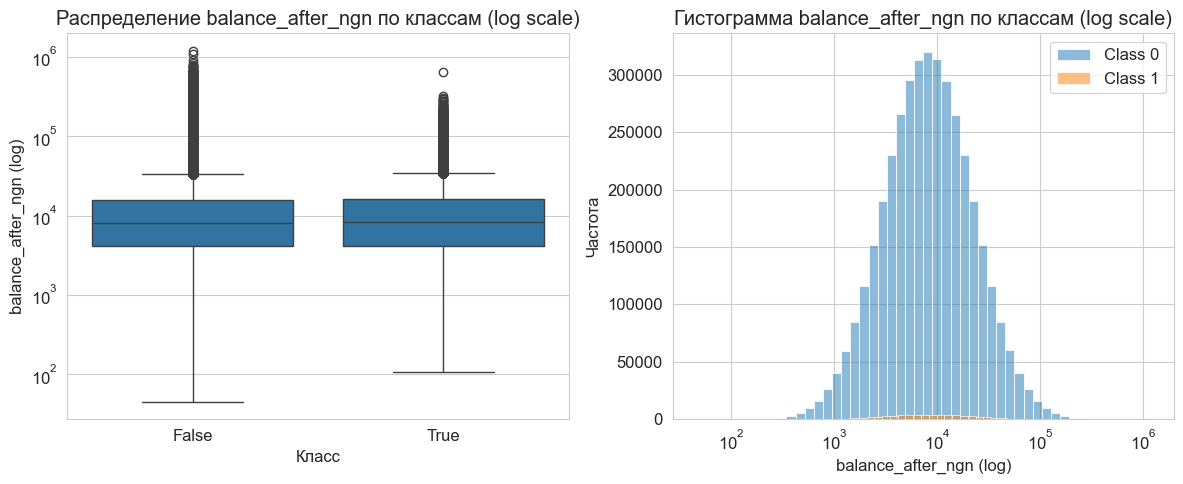

In [12]:
# 5. Визуализация распределения сумм  по классам
for col in ['amount_ngn', 'balance_after_ngn']:

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    sns.boxplot(x='fraud_flag', y=col, data=df)
    plt.yscale('log')  # логарифмическая шкала из-за большого разброса
    plt.title(f'Распределение {col} по классам (log scale)')
    plt.xlabel('Класс')
    plt.ylabel(f'{col} (log)')

    plt.subplot(1,2,2)
    for cls in [0,1]:
        sns.histplot(df[df['fraud_flag']==cls][col], bins=50, label=f'Class {cls}', alpha=0.5, log_scale=True)
    plt.title(f'Гистограмма {col} по классам (log scale)')
    plt.xlabel(f'{col} (log)')
    plt.ylabel('Частота')
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{col}_by_class.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

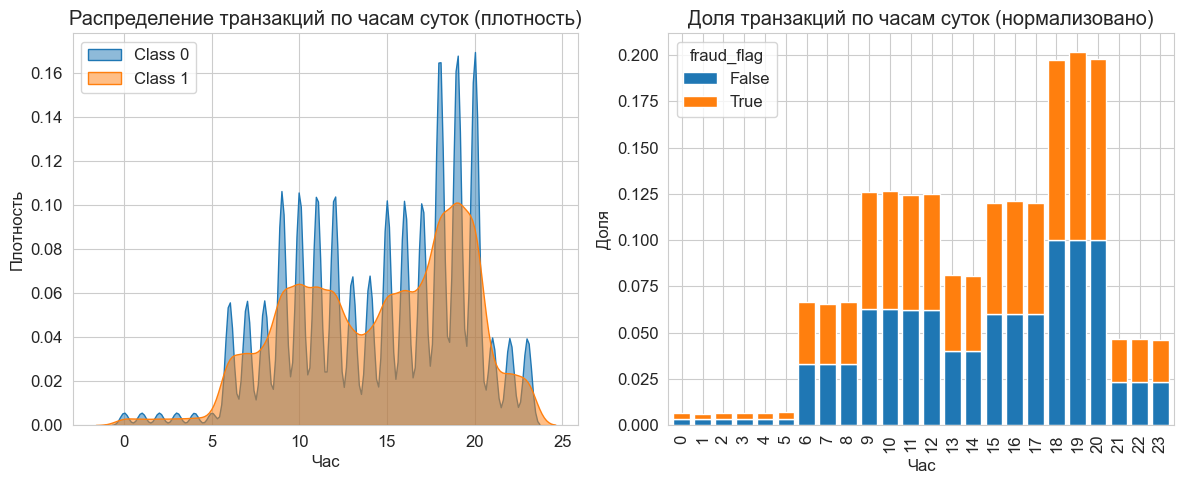

In [13]:
if 'timestamp' in df.columns:
    # Убедимся, что столбец 'hour' существует
    if 'hour' not in df.columns:
        df['hour'] = df['timestamp'].dt.hour
    
    plt.figure(figsize=(12,5))
    # Вариант 1: гистограмма плотности (kde) по часам для каждого класса
    plt.subplot(1,2,1)
    for cls in [False, True]:  # используем оригинальные значения fraud_flag
        subset = df[df['fraud_flag'] == cls]
        sns.kdeplot(subset['hour'], label=f'Class {int(cls)}', fill=True, alpha=0.5)
    plt.title('Распределение транзакций по часам суток (плотность)')
    plt.xlabel('Час')
    plt.ylabel('Плотность')
    plt.legend()
    
    # Вариант 2: stacked bar chart с нормализацией внутри классов
    plt.subplot(1,2,2)
    hourly_counts = df.groupby(['hour', 'fraud_flag']).size().unstack(fill_value=0)
    hourly_norm = hourly_counts.div(hourly_counts.sum(axis=0), axis=1)
    hourly_norm.plot(kind='bar', stacked=True, ax=plt.gca(), width=0.8)
    plt.title('Доля транзакций по часам суток (нормализовано)')
    plt.xlabel('Час')
    plt.ylabel('Доля')
    plt.legend(title='fraud_flag')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'hourly_distribution_by_class.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Сохраним данные по часам для отчёта
    hourly_stats = df.groupby('fraud_flag')['hour'].describe()
else:
    print("Столбец 'timestamp' не найден, временные паттерны пропущены.")

In [14]:


# 8. Генерация отчёта в формате Markdown
report_content = f"""# Отчёт по исследовательскому анализу данных (EDA)

## 1. Общая информация
- **Источник данных**: `{DATA_PATH}`
- **Количество строк**: {df.shape[0]}
- **Количество столбцов**: {df.shape[1]}
- **Типы данных**:
{df.dtypes.to_string()}

## 2. Пропуски
{missing.to_string() if missing.any() else "Пропусков не обнаружено."}

## 3. Распределение классов
| Класс | Количество | Процент |
|-------|------------|--------|
| 0 (норма) | {class_counts[False]} | {class_percents[False]:.2f}% |
| 1 (мошенничество) | {class_counts[True]} | {class_percents[True]:.2f}% |

*Ожидалось ~1% мошеннических транзакций, фактически получено {class_percents[True]:.2f}%.*

![Распределение классов](figures/class_distribution.png)

## 4. Выбросы (метод IQR, коэффициент 1.5)
| Признак | Количество выбросов | Процент |
|---------|-------------------|--------|
| amount_ngn  | {detect_outliers_iqr(df, 'amount_ngn')[False]} | {detect_outliers_iqr(df, 'amount_ngn')[False]/len(df)*100:.2f}% |
| balance_after_ngn    | {detect_outliers_iqr(df, 'balance_after_ngn')[False]}   | {detect_outliers_iqr(df, 'balance_after_ngn')[False]/len(df)*100:.2f}% |


*Примечание: выбросы в сумме транзакций могут быть информативны для выявления мошенничества.*

## 5. Распределение суммы транзакций по классам
На графиках ниже видно, что мошеннические транзакции в основном имеют небольшие суммы (логарифмическая шкала).

![Сумма по классам](figures/amount_by_class.png)

## 6. Временные паттерны
Распределение времени транзакций показывает, что мошеннические операции могут быть сконцентрированы в определённых временных интервалах.

![Временные паттерны](figures/time_patterns.png)

Количество транзакций в интервалах времени:

![Количество транзакций по времени](figures/time_binned_counts.png)

## 7. Корреляционная матрица



![Корреляционная матрица для числовых признаков](figures/correlation_matrix_numeric.png)  
![Корреляционная матрица для категориальных признаков](figures/correlation_matrix_categorical.png)


## 8. Заключение
- Данные не содержат пропусков.
- Классы сильно несбалансированы, что требует специальных методов при построении модели.
- Признак и 'amount_ngn', 'balance_after_ngn' имеют выбросы, и они могут быть важны для обнаружения мошенничества.
- Никаких явных пиков мошеннических транзакций в определённые часы не обнаружено.
![Распределение транзаций по часам](figures/hourly_distribution_by_class.png)
- Сильнай взаимной корреляции между признаками не обнаружено

Отчёт создан автоматически.
"""

# Сохраняем отчёт
with open(REPORT_DIR / 'eda_report.md', 'w', encoding='utf-8') as f:
    f.write(report_content)

print(f"\nОтчёт сохранён в {REPORT_DIR / 'eda_report.md'}")
print(f"Графики сохранены в {FIGURES_DIR}")


Отчёт сохранён в ..\reports\eda_report.md
Графики сохранены в ..\reports\figures


In [15]:
# Для Target Encoding (требуется установка: pip install category_encoders)
try:
    from category_encoders import TargetEncoder
    TARGET_ENCODER_AVAILABLE = True
except ImportError:
    TARGET_ENCODER_AVAILABLE = False
    print("category_encoders not installed. Target Encoding will be skipped.")

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

warnings.filterwarnings("ignore")

In [16]:
# ========================== НАСТРОЙКИ ==========================
DATA_PATH = "../data/raw/nigerian_mobile_money_full.parquet"
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 3

ARTIFACTS_DIR = Path("../models/artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("nigerian_mobile_money_fraud_detection_encoding")

2026/04/23 13:46:58 INFO mlflow.tracking.fluent: Experiment with name 'nigerian_mobile_money_fraud_detection_encoding' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///e:/Data/OTUS/homework/boosting/notebooks/../mlruns/438428238951146523', creation_time=1776941218140, experiment_id='438428238951146523', last_update_time=1776941218140, lifecycle_stage='active', name='nigerian_mobile_money_fraud_detection_encoding', tags={}, workspace='default'>

In [17]:
# ========================== ЗАГРУЗКА И ПРЕДОБРАБОТКА ==========================
def load_data(path: str) -> pd.DataFrame:
    print(f"Загрузка данных из {path}...")
    df = pd.read_parquet(path)
    print(f"Размер данных: {df.shape}")
    return df

def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """Создание временных и относительных признаков, удаление ненужных колонок."""
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["hour"] = df["timestamp"].dt.hour
    df["day_of_week"] = df["timestamp"].dt.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    df["is_night"] = ((df["hour"] >= 22) | (df["hour"] <= 6)).astype(int)

    df["fee_to_amount_ratio"] = df["fee_ngn"] / (df["amount_ngn"] + 1e-5)
    df["balance_to_amount_ratio"] = df["balance_after_ngn"] / (df["amount_ngn"] + 1e-5)
    df["is_round_amount"] = ((df["amount_ngn"] % 1000 == 0) | (df["amount_ngn"] % 5000 == 0)).astype(int)

    drop_cols = ["transaction_id", "wallet_id", "agent_id", "timestamp"]
    df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

    df["fraud_flag"] = df["fraud_flag"].astype(int)
    return df

In [18]:
# ========================== ПОСТРОЕНИЕ ПРЕПРОЦЕССОРА ==========================
def build_preprocessor(categorical_cols: list, method: str = "onehot"):
    """
    Создаёт ColumnTransformer для кодирования категориальных признаков.
    method: 'onehot', 'label', 'target'
    """
    if method == "onehot":
        encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
    elif method == "label":
        # LabelEncoder применяется к каждому столбцу отдельно
        from sklearn.preprocessing import OrdinalEncoder
        encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    elif method == "target":
        if not TARGET_ENCODER_AVAILABLE:
            raise ImportError("TargetEncoder требует библиотеку category_encoders")
        encoder = TargetEncoder()
    else:
        raise ValueError(f"Unknown encoding method: {method}")

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", encoder, categorical_cols)
        ],
        remainder="passthrough"  # числовые признаки остаются без изменений
    )
    return preprocessor


In [19]:
# ========================== РАЗДЕЛЕНИЕ ДАННЫХ ==========================
def split_data(df: pd.DataFrame, target_col: str, test_size: float, random_state: int):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
    return X_train, X_test, y_train, y_test

In [20]:
def balance_dataset(X: pd.DataFrame, y: pd.Series, random_state: int = 42):
    """
    Балансировка набора данных путём даунсэмплинга мажорного класса до размера минорного.
    Возвращает сбалансированные X_balanced, y_balanced.
    """
    # Объединяем для удобства
    data = X.copy()
    data['__target__'] = y.values

    # Разделяем по классам
    majority_class = data[data['__target__'] == 0]
    minority_class = data[data['__target__'] == 1]

    # Даунсэмплинг мажорного класса
    majority_downsampled = resample(
        majority_class,
        replace=False,
        n_samples=len(minority_class),
        random_state=random_state
    )

    # Объединяем обратно
    balanced_data = pd.concat([majority_downsampled, minority_class], axis=0).sample(frac=1, random_state=random_state)

    y_balanced = balanced_data['__target__']
    X_balanced = balanced_data.drop(columns=['__target__'])
    return X_balanced, y_balanced

In [21]:
# ========================== ОБУЧЕНИЕ И ОЦЕНКА ==========================
def train_and_evaluate(model, model_name: str, X_train, y_train, X_test, y_test, preprocessor=None):
    """
    Обучение модели (с препроцессором в Pipeline, если передан).
    Логирование в MLflow.
    """
    with mlflow.start_run(run_name=model_name):
        if preprocessor is not None:
            pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)
            y_proba = pipeline.predict_proba(X_test)[:, 1]
            trained_model = pipeline
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
            trained_model = model

        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_auc = np.trapz(recall, precision) if y_proba is not None else np.nan

        params = model.get_params()
        mlflow.log_params(params)
        mlflow.log_metrics({
            "accuracy": accuracy,
            "f1_score": f1,
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
        })

        signature = infer_signature(X_train, trained_model.predict(X_train))
        mlflow.sklearn.log_model(trained_model, "model", signature=signature)

        # Важность признаков (если модель внутри pipeline)
        if hasattr(trained_model, "named_steps"):
            classifier = trained_model.named_steps["classifier"]
        else:
            classifier = trained_model
        if hasattr(classifier, "feature_importances_"):
            # Получение имён признаков после препроцессинга
            if preprocessor:
                feature_names = preprocessor.get_feature_names_out()
            else:
                feature_names = X_train.columns
            importances = classifier.feature_importances_
            fi_df = pd.DataFrame({"feature": feature_names, "importance": importances})
            fi_df = fi_df.sort_values("importance", ascending=False).head(20)
            fi_path = ARTIFACTS_DIR / f"{model_name}_feature_importance.csv"
            fi_df.to_csv(fi_path, index=False)
            mlflow.log_artifact(str(fi_path))

        print(f"{model_name} - ROC-AUC: {roc_auc:.4f}, PR-AUC: {pr_auc:.4f}, F1: {f1:.4f}")
        return {
            "model": trained_model,
            "accuracy": accuracy,
            "f1": f1,
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
        }


In [22]:
# ========================== ТЮНИНГ ==========================
def tune_hyperparameters_optuna(
    model,
    param_suggestions: dict,
    X_train,
    y_train,
    model_name: str,
    preprocessor=None,
    timeout: int = 300,
    n_splits: int = 3,
    random_state: int = 42,
    balance_training: bool = True,   # <-- новый параметр
):
    """
    Настройка гиперпараметров с Optuna.
    Если balance_training=True, то внутри каждого фолда обучающая часть балансируется.
    """

    supports_early_stopping = model_name.lower() in ["xgb", "lgbm", "catboost"]

    def objective(trial):
        # Сбор параметров
        params = {}
        for param_name, suggest_spec in param_suggestions.items():
            suggest_type = suggest_spec[0]
            if suggest_type == "int":
                params[param_name] = trial.suggest_int(param_name, *suggest_spec[1:])
            elif suggest_type == "float":
                if len(suggest_spec) > 2 and isinstance(suggest_spec[-1], str):
                    params[param_name] = trial.suggest_float(
                        param_name, suggest_spec[1], suggest_spec[2], log=(suggest_spec[-1]=='log')
                    )
                else:
                    params[param_name] = trial.suggest_float(param_name, *suggest_spec[1:])
            elif suggest_type == "categorical":
                params[param_name] = trial.suggest_categorical(param_name, suggest_spec[1])

        # Создаём экземпляр модели
        if model_name.lower().startswith("xgb"):
            model_instance = XGBClassifier(
                **params, random_state=random_state, use_label_encoder=False,
                eval_metric="logloss", verbosity=0
            )
        elif model_name.lower().startswith("lgbm"):
            model_instance = LGBMClassifier(
                **params, random_state=random_state, verbose=-1
            )
        elif model_name.lower().startswith("catboost"):
            model_instance = CatBoostClassifier(
                **params, random_state=random_state, verbose=0
            )
        else:
            model_instance = GradientBoostingClassifier(
                **params, random_state=random_state
            )

        # Оборачиваем в Pipeline при наличии препроцессора
        if preprocessor is not None:
            pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model_instance)])
            estimator = pipeline
        else:
            estimator = model_instance

        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        scores = []

        for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
            X_fold_train = X_train.iloc[train_idx]
            y_fold_train = y_train.iloc[train_idx]
            X_fold_val = X_train.iloc[val_idx]
            y_fold_val = y_train.iloc[val_idx]

            # Балансировка обучающей части фолда
            if balance_training:
                X_fold_train, y_fold_train = balance_dataset(X_fold_train, y_fold_train, random_state=random_state)

            # Обучение с ранней остановкой для поддерживаемых моделей
            if supports_early_stopping:
                if model_name.lower().startswith("xgb"):
                    estimator.fit(
                        X_fold_train, y_fold_train,
                        classifier__eval_set=[(X_fold_val, y_fold_val)],
                        classifier__early_stopping_rounds=10,
                        classifier__verbose=False,
                    )
                elif model_name.lower().startswith("lgbm"):
                    import lightgbm as lgb
                    estimator.fit(
                        X_fold_train, y_fold_train,
                        classifier__eval_set=[(X_fold_val, y_fold_val)],
                        classifier__callbacks=[lgb.early_stopping(10), lgb.log_evaluation(0)],
                    )
                elif model_name.lower().startswith("catboost"):
                    estimator.fit(
                        X_fold_train, y_fold_train,
                        classifier__eval_set=[(X_fold_val, y_fold_val)],
                        classifier__early_stopping_rounds=10,
                        classifier__verbose=False,
                    )
            else:
                estimator.fit(X_fold_train, y_fold_train)

            # Предсказание вероятностей
            if hasattr(estimator, "predict_proba"):
                y_proba = estimator.predict_proba(X_fold_val)[:, 1]
            else:
                y_proba = estimator.decision_function(X_fold_val)
                y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())

            roc_auc = roc_auc_score(y_fold_val, y_proba)
            scores.append(roc_auc)

            trial.report(roc_auc, fold_idx)
            if trial.should_prune():
                raise optuna.TrialPruned()

        return np.mean(scores)

    # Создаём исследование Optuna
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=random_state),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0, interval_steps=1),
    )

    study.optimize(objective, timeout=timeout, n_jobs=1, show_progress_bar=True)

    best_params = study.best_params
    best_score = study.best_value

    # Финальное обучение на всех тренировочных данных (опционально балансируем)
    if balance_training:
        X_train_balanced, y_train_balanced = balance_dataset(X_train, y_train, random_state=random_state)
    else:
        X_train_balanced, y_train_balanced = X_train, y_train

    if model_name.lower().startswith("xgb"):
        final_model = XGBClassifier(
            **best_params, random_state=random_state, use_label_encoder=False,
            eval_metric="logloss", verbosity=0
        )
    elif model_name.lower().startswith("lgbm"):
        final_model = LGBMClassifier(**best_params, random_state=random_state, verbose=-1)
    elif model_name.lower().startswith("catboost"):
        final_model = CatBoostClassifier(**best_params, random_state=random_state, verbose=0)
    else:
        final_model = GradientBoostingClassifier(**best_params, random_state=random_state)

    if preprocessor is not None:
        final_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", final_model)])
        final_pipeline.fit(X_train_balanced, y_train_balanced)
        final_estimator = final_pipeline
    else:
        final_model.fit(X_train_balanced, y_train_balanced)
        final_estimator = final_model

    # Логирование в MLflow
    with mlflow.start_run(run_name=f"{model_name}_optuna_balanced"):
        mlflow.log_params(best_params)
        mlflow.log_metric("cv_roc_auc", best_score)
        mlflow.sklearn.log_model(final_estimator, "model")
        trials_df = study.trials_dataframe()
        trials_path = ARTIFACTS_DIR / f"{model_name}_optuna_trials.csv"
        trials_df.to_csv(trials_path, index=False)
        mlflow.log_artifact(str(trials_path))
        #print(f"{model_name} Optuna tuned (balanced) - Best CV ROC-AUC: {best_score:.4f}")

    return final_estimator

In [23]:
# ========================== ВИЗУАЛИЗАЦИЯ ==========================
def plot_metrics_comparison(results_df: pd.DataFrame, title: str = "Model Comparison"):
    metrics = ["roc_auc", "pr_auc", "f1"]
    df_melt = results_df.melt(
        id_vars="model", value_vars=metrics, var_name="metric", value_name="value"
    )
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_melt, x="model", y="value", hue="metric")
    plt.title(title)
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.legend(title="Metric")
    plt.tight_layout()
    plot_path = ARTIFACTS_DIR / f"{title.replace(' ', '_')}.png"
    plt.savefig(plot_path, dpi=150)
    plt.show()
    return plot_path

In [24]:
df = load_data(DATA_PATH)
df = preprocess_data(df)

# Определяем категориальные колонки (все строковые/категориальные, кроме целевой)
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Категориальные признаки: {categorical_cols}")


Загрузка данных из ../data/raw/nigerian_mobile_money_full.parquet...
Размер данных: (4000000, 13)
Категориальные признаки: ['transaction_type', 'channel', 'device_os', 'kyc_tier']


In [25]:
# Разделение (без кодирования, чтобы препроцессор работал с оригинальными категориями)
X_train_raw, X_test_raw, y_train, y_test = split_data(
        df, "fraud_flag", TEST_SIZE, RANDOM_STATE
    )

# Список методов кодирования
encoding_methods = ["onehot", "label"]
if TARGET_ENCODER_AVAILABLE:
    encoding_methods.append("target")
else:
    print("Target Encoding пропущен (нет category_encoders).")

Train size: (3200000, 15), Test size: (800000, 15)



Метод кодирования: ONEHOT


2026/04/23 13:47:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 13:47:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


onehot_GradientBoosting - ROC-AUC: 0.9547, PR-AUC: 0.1640, F1: 0.3074


2026/04/23 13:47:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 13:47:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


onehot_XGBoost - ROC-AUC: 0.9543, PR-AUC: 0.1623, F1: 0.3076


...

[I 2026-04-23 14:38:12,549] Trial 14 pruned. 


Best trial: 0. Best value: 0.956512:  100%|██████████| 03:05/03:00


[I 2026-04-23 14:38:30,903] Trial 15 finished with value: 0.9563542776495136 and parameters: {'iterations': 175, 'depth': 8, 'learning_rate': 0.03876930129399186, 'l2_leaf_reg': 6.1585300706030335}. Best is trial 0 with value: 0.9565119939631758.


2026/04/23 14:38:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 14:38:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== Сводка по базовым моделям ===
   encoding                    model   roc_auc    pr_auc        f1
0    onehot  onehot_GradientBoosting  0.954692  0.164029  0.307406
1    onehot           onehot_XGBoost  0.954260  0.162333  0.307642
2    onehot          onehot_CatBoost  0.954862  0.164126  0.307715
3    onehot          onehot_LightGBM  0.954487  0.164802  0.307597
4     label   label_GradientBoosting  0.954867  0.164587  0.307293
5     label            label_XGBoost  0.955037  0.166176  0.307626
6     label           label_CatBoost  0.954960  0.164313  0.307638
7     label           label_LightGBM  0.954842  0.167316  0.307690
8    target  target_GradientBoosting  0.954842  0.164867  0.307140
9    target           target_XGBoost  0.954431  0.164784  0.307603
10   target          target_CatBoost  0.955079  0.164693  0.307692
11   target          target_LightGBM  0.954535  0.164159  0.307571

=== Сводка по настроенным моделям ===
   encoding                          model   roc_auc   

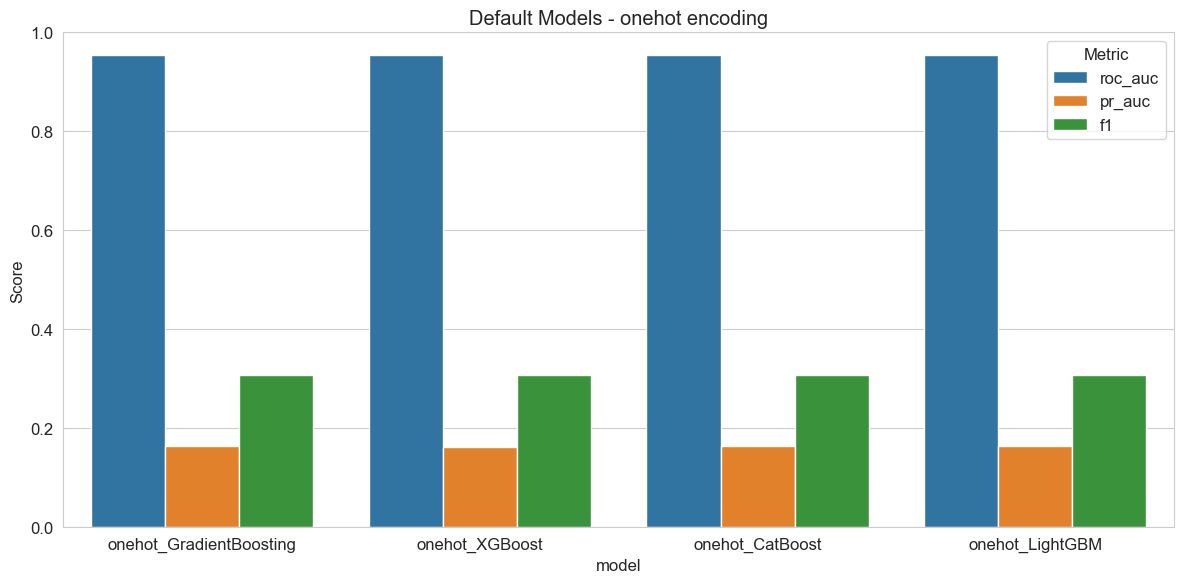

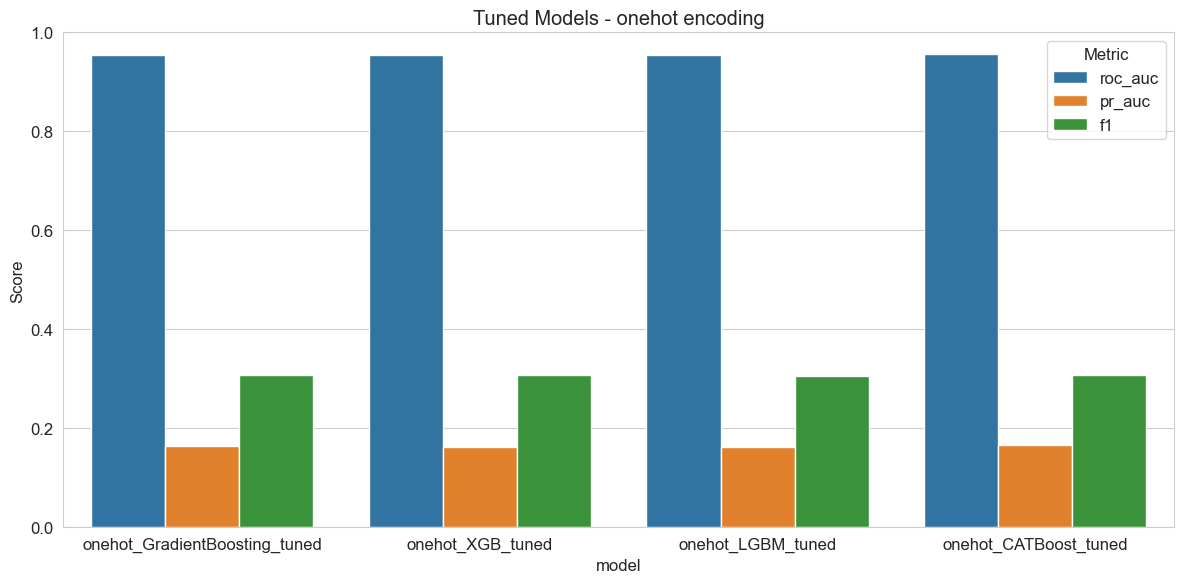

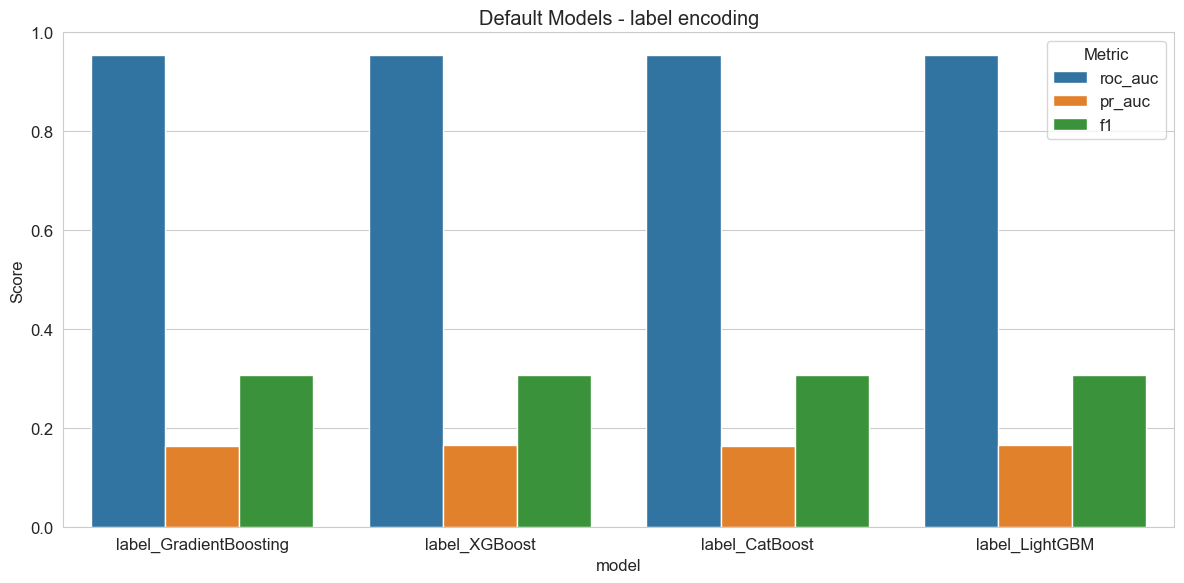

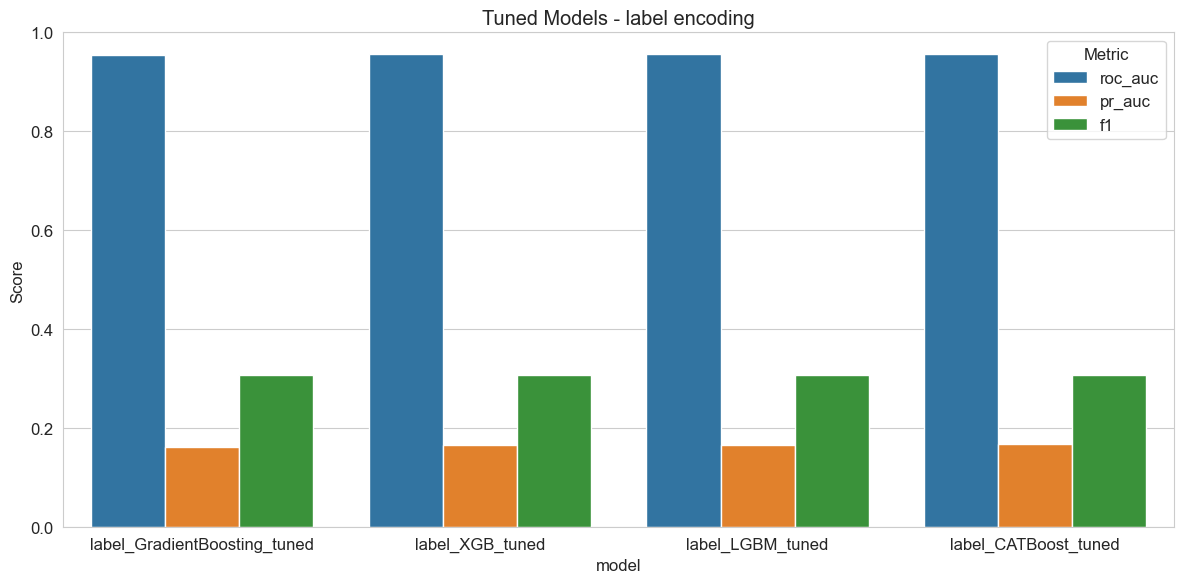

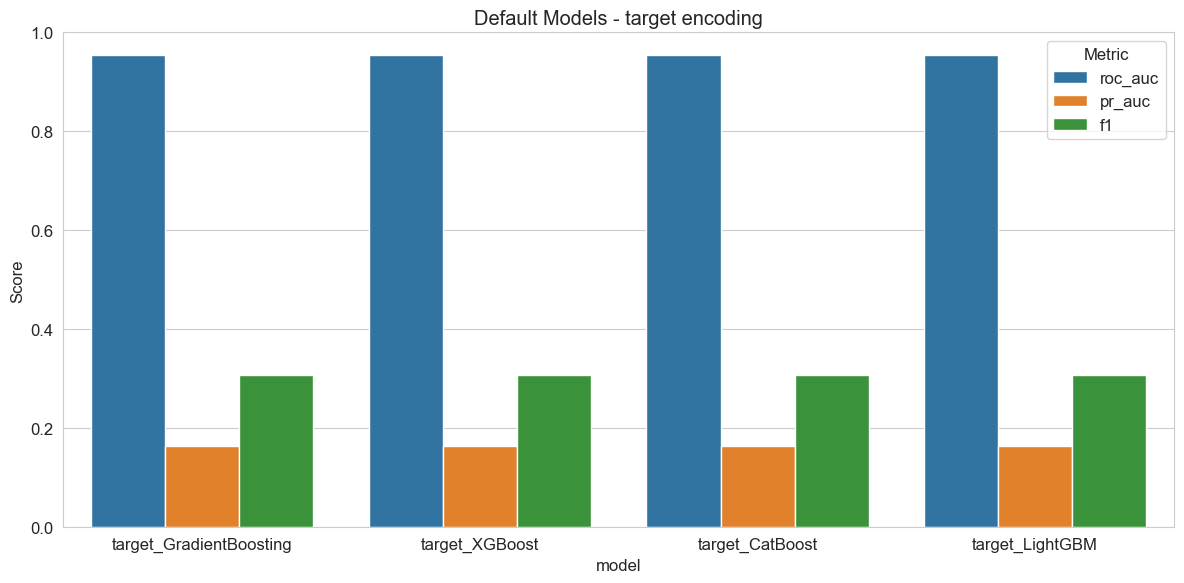

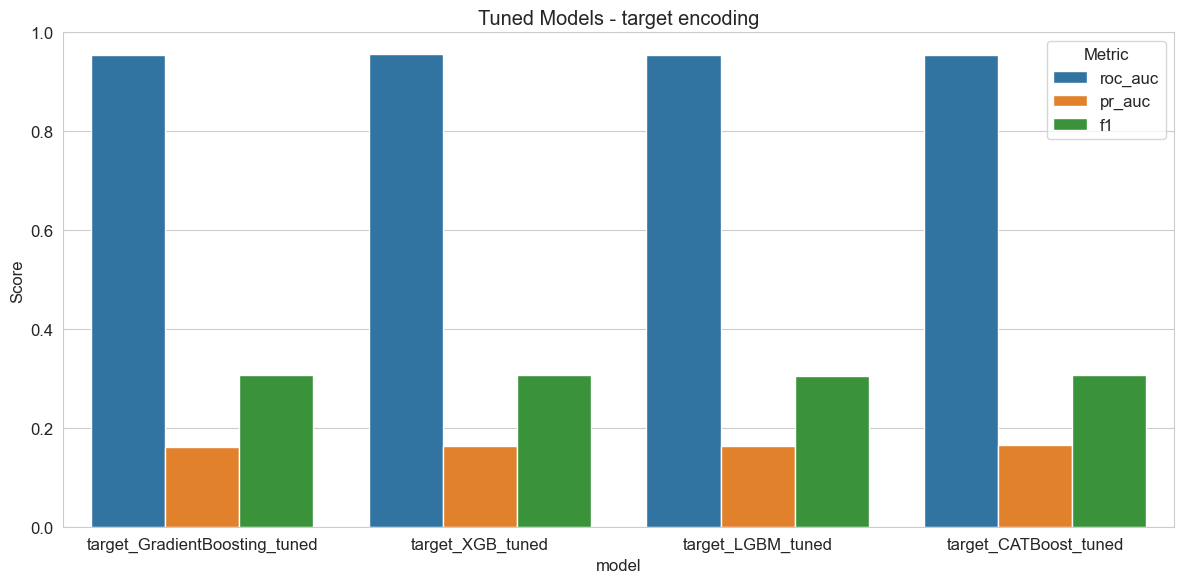


Отчёт сохранён в ..\models\artifacts\final_report_encoding_comparison.md


In [26]:
all_results_default = []
all_results_tuned = []

for enc_method in encoding_methods:
    print(f"\n{'='*50}\nМетод кодирования: {enc_method.upper()}\n{'='*50}")
    # Создаём препроцессор для текущего метода
    preprocessor = build_preprocessor(categorical_cols, method=enc_method)
    # Базовые модели с препроцессором
    models_default = {
            f"{enc_method}_GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
            f"{enc_method}_XGBoost": XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False, eval_metric="logloss"),
            f"{enc_method}_CatBoost": CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
            f"{enc_method}_LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    }
    X_train_balanced, y_train_balanced = balance_dataset(X_train_raw, y_train, random_state=RANDOM_STATE)
    for name, model in models_default.items():
        res = train_and_evaluate(
            model, name, X_train_balanced, y_train_balanced, X_test_raw, y_test,
                preprocessor=preprocessor
        )
        all_results_default.append({
            "encoding": enc_method,
            "model": name,
            "roc_auc": res["roc_auc"],
            "pr_auc": res["pr_auc"],
            "f1": res["f1"],
        })
        
    # Настройка гиперпараметров (для каждой модели своя сетка)
    gb_param_space = {
            "n_estimators": ("int", 50, 300),
            "max_depth": ("int", 3, 8),
            "learning_rate": ("float", 0.01, 0.3, "log"),
            "subsample": ("float", 0.6, 1.0),
        }
        
    # Для XGBoost
    xgb_param_space = {
            "n_estimators": ("int", 50, 300),
            "max_depth": ("int", 3, 8),
            "learning_rate": ("float", 0.01, 0.3, "log"),
            "subsample": ("float", 0.6, 1.0),
            "colsample_bytree": ("float", 0.6, 1.0),
        }

    # Для CatBoost
    cb_param_space = {
            "iterations": ("int", 50, 300),
            "depth": ("int", 3, 8),
            "learning_rate": ("float", 0.01, 0.3, "log"),
            "l2_leaf_reg": ("float", 1, 10, "log"),
        }

    # Для LightGBM
    lgb_param_space = {
            "n_estimators": ("int", 50, 300),
            "max_depth": ("int", 3, 8),
            "learning_rate": ("float", 0.01, 0.3, "log"),
            "subsample": ("float", 0.6, 1.0),
            "colsample_bytree": ("float", 0.6, 1.0),
        }
    hyper_dic ={'GradientBoosting_tuned':[GradientBoostingClassifier, gb_param_space],
                    'XGB_tuned':[XGBClassifier, xgb_param_space],
                    'LGBM_tuned':[LGBMClassifier, lgb_param_space],
                    'CATBoost_tuned':[CatBoostClassifier, cb_param_space]}
    tuned_models = {}
    for name, model_specs in hyper_dic.items():
        tuned_models[f"{enc_method}_{name}"] = tune_hyperparameters_optuna(
                model=model_specs[0],
                param_suggestions=model_specs[1],
                X_train=X_train_raw,
                y_train=y_train,
                model_name=f"{name}_{enc_method}",
                preprocessor=preprocessor,
                timeout=180,  # 5 минут
            )
    # Оценка настроенных моделей на тесте

    for name, model_pipeline in tuned_models.items():
        y_pred = model_pipeline.predict(X_test_raw)
        y_proba = model_pipeline.predict_proba(X_test_raw)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_auc = np.trapz(recall, precision)
        f1 = f1_score(y_test, y_pred)

        with mlflow.start_run(run_name=f"{name}_test_eval"):
            mlflow.log_metrics({"roc_auc": roc_auc, "pr_auc": pr_auc, "f1": f1})

        all_results_tuned.append({
                "encoding": enc_method,
                "model": name,
                "roc_auc": roc_auc,
                "pr_auc": pr_auc,
                "f1": f1,
            })

# Сохранение и визуализация результатов
df_default = pd.DataFrame(all_results_default)
df_tuned = pd.DataFrame(all_results_tuned)

print("\n=== Сводка по базовым моделям ===")
print(df_default)
print("\n=== Сводка по настроенным моделям ===")
print(df_tuned)

# Графики сравнения по методам кодирования
for enc in encoding_methods:
    sub_default = df_default[df_default["encoding"] == enc]
    if not sub_default.empty:
        plot_metrics_comparison(sub_default, f"Default Models - {enc} encoding")
    sub_tuned = df_tuned[df_tuned["encoding"] == enc]
    if not sub_tuned.empty:
        plot_metrics_comparison(sub_tuned, f"Tuned Models - {enc} encoding")

# Итоговый отчёт
report = f"""# Отчёт по сравнению моделей и методов кодирования

        ## Базовые модели (параметры по умолчанию)
        {df_default.to_markdown(index=False)}

        ## Настроенные модели (после GridSearchCV)
        {df_tuned.to_markdown(index=False)}

        ## Лучшие результаты
        - **Базовые модели:**
        - ROC-AUC: {df_default.loc[df_default['roc_auc'].idxmax(), 'model']} ({df_default['roc_auc'].max():.4f})
        - PR-AUC: {df_default.loc[df_default['pr_auc'].idxmax(), 'model']} ({df_default['pr_auc'].max():.4f})
        - **Настроенные модели:**
        - ROC-AUC: {df_tuned.loc[df_tuned['roc_auc'].idxmax(), 'model']} ({df_tuned['roc_auc'].max():.4f})
        - PR-AUC: {df_tuned.loc[df_tuned['pr_auc'].idxmax(), 'model']} ({df_tuned['pr_auc'].max():.4f})

        Все эксперименты сохранены в MLflow (`../mlruns`).
        """
report_path = ARTIFACTS_DIR / "final_report_encoding_comparison.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)
print(f"\nОтчёт сохранён в {report_path}")